#Financial News Sentiment Classifier

In [35]:
# ── 1. INSTALL & IMPORTS ──────────────────────────────────────────────────────
!pip install datasets transformers torch scikit-learn

import os, time
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

In [36]:
# ── 2. CONFIG ─────────────────────────────────────────────────────────────────
MODEL_NAME   = "bert-base-uncased"
MAX_LENGTH   = 64        # financial sentences are short
BATCH_SIZE   = 16
NUM_EPOCHS   = 5
LR           = 2e-5
WEIGHT_DECAY = 0.01
EVAL_FREQ    = 50
EVAL_ITER    = 20
SEED         = 123
NUM_CLASSES  = 3

torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [37]:
# ── 3. LOAD DATASET ───────────────────────────────────────────────────────────
ds = load_dataset("atrost/financial_phrasebank")
print(ds)

# ALWAYS verify label mapping first
label_feature = ds["train"].features["label"]
print("\nVerified label mapping:")
for i, name in enumerate(label_feature.names):
    print(f"  {i} → {name}")
# 0 → negative | 1 → neutral | 2 → positive

label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 3100
    })
    validation: Dataset({
        features: ['sentence', 'label'],
        num_rows: 776
    })
    test: Dataset({
        features: ['sentence', 'label'],
        num_rows: 970
    })
})

Verified label mapping:
  0 → negative
  1 → neutral
  2 → positive


In [38]:
# ── 4. CONVERT TO CSV ─────────────────────────────────────────────────────────
train_df = ds["train"].to_pandas()
val_df   = ds["validation"].to_pandas()
test_df  = ds["test"].to_pandas()

train_df.to_csv("train.csv", index=None)
val_df.to_csv("validation.csv",   index=None)
test_df.to_csv("test.csv",  index=None)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nLabel distribution (train):\n{train_df['label'].value_counts().sort_index()}")

Train: 3100 | Val: 776 | Test: 970

Label distribution (train):
label
0     382
1    1852
2     866
Name: count, dtype: int64


In [39]:
# ── 5. TOKENIZER ──────────────────────────────────────────────────────────────
# BERT uses WordPiece tokenizer — replaces tiktoken from your GPT project
# [CLS] and [SEP] tokens added automatically
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer: {MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size}")
print(f"Special tokens — [CLS]: {tokenizer.cls_token_id}, [SEP]: {tokenizer.sep_token_id}, [PAD]: {tokenizer.pad_token_id}")

Tokenizer: bert-base-uncased
Vocab size: 30522
Special tokens — [CLS]: 101, [SEP]: 102, [PAD]: 0


In [40]:
# ── 6. DATASET CLASS ──────────────────────────────────────────────────────────
# Same structure as your NewsDataset — reads CSV, tokenizes, pads
# Key difference: BERT tokenizer handles padding internally
# and returns attention_mask (1=real token, 0=pad) alongside input_ids

class FinancialDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=MAX_LENGTH):
        self.data       = pd.read_csv(csv_file)
        self.tokenizer  = tokenizer
        self.max_length = max_length

        # Batch tokenize — pads & truncates to max_length
        # Returns input_ids + attention_mask tensors
        self.encodings = tokenizer(
            list(self.data["sentence"]),
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

    def __getitem__(self, index):
        return (
            self.encodings["input_ids"][index],       # token ids
            self.encodings["attention_mask"][index],  # 1=real, 0=pad
            torch.tensor(self.data.iloc[index]["label"], dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)


train_dataset = FinancialDataset("train.csv",      tokenizer)
val_dataset   = FinancialDataset("validation.csv", tokenizer)
test_dataset  = FinancialDataset("test.csv",       tokenizer)

print(f"Max length: {MAX_LENGTH} tokens")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Max length: 64 tokens
Train: 3100 | Val: 776 | Test: 970


In [41]:
# ── 7. DATALOADERS ────────────────────────────────────────────────────────────
# Identical pattern to your project
num_workers = 2
torch.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=num_workers, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          num_workers=num_workers, drop_last=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          num_workers=num_workers, drop_last=False)

print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

193 training batches
49 validation batches
61 test batches


In [42]:
# ── 8. LOAD PRETRAINED BERT ───────────────────────────────────────────────────
# In your project: manually downloaded safetensors + load_weights_into_gpt()
# Here: HuggingFace handles it in one line — same concept, cleaner API
#
# AutoModelForSequenceClassification automatically:
#   - loads pretrained BERT weights (like your load_weights_into_gpt)
#   - adds a classification head on top (like your gpt.out_head replacement)
#   - sets num_labels=3 for 3-class output

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {MODEL_NAME}")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: bert-base-uncased
Total parameters:     109,484,547
Trainable parameters: 109,484,547


In [61]:

# Run this right after loading the model, before any training

import torch.nn as nn

class RegularizedClassifier(nn.Module):
    def __init__(self, hidden_size=768, num_labels=3, dropout_prob=0.3):
        super().__init__()
        self.dropout = nn.Dropout(dropout_prob)   # ← kills 30% of neurons randomly
        self.linear  = nn.Linear(hidden_size, num_labels)

    def forward(self, x):
        return self.linear(self.dropout(x))       # dropout → then classify

model.classifier = RegularizedClassifier(
    hidden_size=768,
    num_labels=NUM_CLASSES,
    dropout_prob=0.3
).to(device)

print("Classifier replaced with dropout version")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Classifier replaced with dropout version
Trainable params: 109,484,547


In [64]:
# ── SELECTIVE LAYER FREEZING ──────────────────────────────────────────────────
# Freeze bottom 8 layers, train top 4 + pooler + classifier

# First freeze everything
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only the top 4 transformer layers (layers 8, 9, 10, 11)
for i in range(8, 12):
    for param in model.bert.encoder.layer[i].parameters():
        param.requires_grad = True

# Always unfreeze pooler and classifier
for param in model.bert.pooler.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
# Expect ~28M / 110M (~25%) — enough to learn, not enough to overfit

Trainable: 28,944,387 / 109,484,547 (26.4%)


In [65]:
# ── 10. LOSS — start WITHOUT class weights ────────────────────────────────────
#
# Class weights at initialization amplify the random classifier's bad outputs.
# Train for 1-2 epochs first, then optionally add weights if Negative F1 is low.

criterion = nn.CrossEntropyLoss()   # plain, no weights to start

def calc_loss_batch(input_ids, attention_mask, labels, model, device):
    input_ids      = input_ids.to(device)
    attention_mask = attention_mask.to(device)
    labels         = labels.to(device)
    outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
    return criterion(outputs.logits, labels)

# ... rest of calc_loss_loader, calc_accuracy_loader, evaluate_model unchanged

In [66]:
# ── UPDATED OPTIMIZER ─────────────────────────────────────────────────────────
torch.manual_seed(SEED)

optimizer    = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.1)
                                                    # ↑ was 2e-5   ↑ was 0.01
total_steps  = NUM_EPOCHS * len(train_loader)
warmup_steps = int(0.1 * total_steps)              # 10% warmup (was 6%)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.0, 1.0 - progress)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [67]:

print("── Pre-training baseline ──")
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss   = calc_loss_loader(val_loader,   model, device, num_batches=5)

train_acc = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_acc   = calc_accuracy_loader(val_loader,   model, device, num_batches=10)
test_acc  = calc_accuracy_loader(test_loader,  model, device, num_batches=10)

print(f"Train loss: {train_loss:.3f} | Val loss: {val_loss:.3f}")
print(f"Training accuracy:   {train_acc*100:.2f}%")
print(f"Validation accuracy: {val_acc*100:.2f}%")
print(f"Test accuracy:       {test_acc*100:.2f}%")
# Loss ~1.09, accuracy anywhere from 25–45% is all fine — random head on 3 classes

── Pre-training baseline ──
Train loss: 1.089 | Val loss: 1.115
Training accuracy:   41.25%
Validation accuracy: 45.00%
Test accuracy:       40.62%


In [68]:
#Train
def train_classifier_simple(model, train_loader, val_loader, optimizer, scheduler,
                             device, num_epochs, eval_freq, eval_iter, patience=3):

    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1
    best_val_loss    = float("inf")
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()

        for input_ids, attention_mask, labels in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_ids, attention_mask, labels, model, device)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            examples_seen += input_ids.shape[0]
            global_step   += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f} | Val loss {val_loss:.3f} | "
                      f"LR {scheduler.get_last_lr()[0]:.2e}")

        train_acc = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_acc   = calc_accuracy_loader(val_loader,   model, device, num_batches=eval_iter)
        print(f"  Training accuracy: {train_acc*100:.2f}% | "
              f"Validation accuracy: {val_acc*100:.2f}%")
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        epoch_val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
        if epoch_val_loss < best_val_loss:
            best_val_loss    = epoch_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pt")
            print(f"  ✓ Best model saved (val loss {best_val_loss:.3f})")
        else:
            patience_counter += 1
            print(f"  ✗ No improvement ({patience_counter}/{patience})")
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(torch.load("best_model.pt"))
    return train_losses, val_losses, train_accs, val_accs, examples_seen


#CALL
torch.manual_seed(SEED)
start_time = time.time()

train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, scheduler, device,
    NUM_EPOCHS, EVAL_FREQ, EVAL_ITER,
    patience=3
)

print(f"\nTraining completed in {(time.time()-start_time)/60:.2f} minutes.")

Ep 1 (Step 000000): Train loss 1.093 | Val loss 1.097 | LR 3.12e-07
Ep 1 (Step 000050): Train loss 0.821 | Val loss 0.838 | LR 1.59e-05
Ep 1 (Step 000100): Train loss 0.675 | Val loss 0.652 | LR 2.98e-05
Ep 1 (Step 000150): Train loss 0.426 | Val loss 0.482 | LR 2.81e-05
  Training accuracy: 89.38% | Validation accuracy: 80.31%
  ✓ Best model saved (val loss 0.422)
Ep 2 (Step 000200): Train loss 0.375 | Val loss 0.425 | LR 2.64e-05
Ep 2 (Step 000250): Train loss 0.307 | Val loss 0.401 | LR 2.46e-05
Ep 2 (Step 000300): Train loss 0.294 | Val loss 0.396 | LR 2.29e-05
Ep 2 (Step 000350): Train loss 0.277 | Val loss 0.394 | LR 2.12e-05
  Training accuracy: 92.19% | Validation accuracy: 82.50%
  ✗ No improvement (1/3)
Ep 3 (Step 000400): Train loss 0.311 | Val loss 0.435 | LR 1.95e-05
Ep 3 (Step 000450): Train loss 0.171 | Val loss 0.375 | LR 1.77e-05
Ep 3 (Step 000500): Train loss 0.147 | Val loss 0.389 | LR 1.60e-05
Ep 3 (Step 000550): Train loss 0.146 | Val loss 0.371 | LR 1.43e-05
  Tra

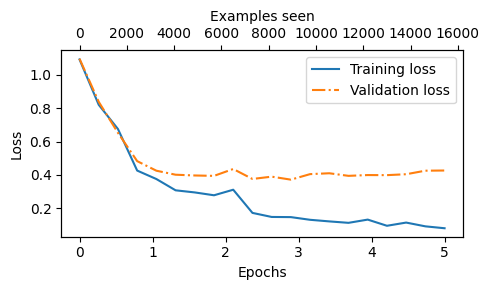

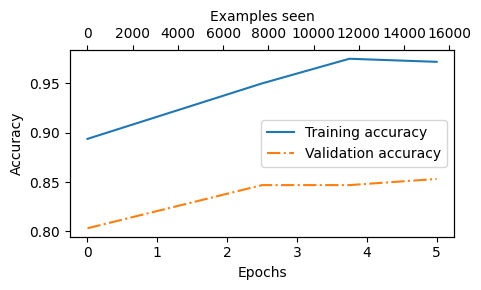

In [69]:
def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("Examples seen")
    fig.tight_layout()
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

# Use NUM_EPOCHS from config and the actual examples_seen from training
epochs_tensor   = torch.linspace(0, NUM_EPOCHS, len(train_losses))
examples_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_tensor, train_losses, val_losses)

# Accuracy was recorded per epoch, so scale tensors accordingly
epochs_acc   = torch.linspace(0, NUM_EPOCHS, len(train_accs))
examples_acc = torch.linspace(0, examples_seen, len(train_accs))
plot_values(epochs_acc, examples_acc, train_accs, val_accs, label="accuracy")

In [70]:
# ── 14. FINAL ACCURACY ────────────────────────────────────────────────────────
# Updated to use 'model' instead of 'gpt'
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy   = calc_accuracy_loader(val_loader,   model, device)
test_accuracy  = calc_accuracy_loader(test_loader,  model, device)

print(f"Final Training accuracy:   {train_accuracy*100:.2f}%")
print(f"Final Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Final Test accuracy:       {test_accuracy*100:.2f}%")

Final Training accuracy:   94.98%
Final Validation accuracy: 84.54%
Final Test accuracy:       85.26%



Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.85      0.84       125
     Neutral       0.88      0.89      0.89       565
    Positive       0.80      0.78      0.79       280

    accuracy                           0.85       970
   macro avg       0.84      0.84      0.84       970
weighted avg       0.85      0.85      0.85       970



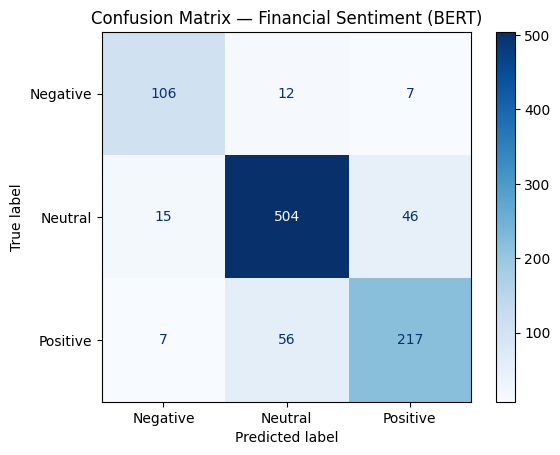

In [72]:
# ── CLASSIFICATION REPORT + CONFUSION MATRIX ──────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for input_ids, attn_mask, labels in test_loader:
        outputs = model(input_ids=input_ids.to(device),
                        attention_mask=attn_mask.to(device))
        preds   = torch.argmax(outputs.logits, dim=-1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print("\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=["Negative", "Neutral", "Positive"]
))

cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Negative", "Neutral", "Positive"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Financial Sentiment (BERT)")
plt.savefig("confusion_matrix.pdf")
plt.show()

In [73]:
# ── ERROR ANALYSIS: 10 misclassified examples ─────────────────────────────────
print("\n── 10 misclassified examples ──")
test_df_reset = test_df.reset_index(drop=True)
errors = []
model.eval()

with torch.no_grad():
    for i in range(len(test_dataset)):
        ids, mask, true_label = test_dataset[i]
        outputs    = model(input_ids=ids.unsqueeze(0).to(device),
                           attention_mask=mask.unsqueeze(0).to(device))
        pred_label = torch.argmax(outputs.logits, dim=-1).item()

        if pred_label != true_label.item():
            errors.append({
                "text":      test_df_reset.iloc[i]["sentence"],
                "true":      label_map[true_label.item()],
                "predicted": label_map[pred_label]
            })
        if len(errors) == 10:
            break

for j, e in enumerate(errors, 1):
    print(f"\n[{j}] {e['text']}")
    print(f"    True: {e['true']}  →  Predicted: {e['predicted']}")


── 10 misclassified examples ──

[1] `` Rapala is excited to be partnering with RBFF and other industry leaders on this holiday promotion . ''
    True: Neutral  →  Predicted: Positive

[2] Ramirent is the leading construction machinery rental company in Finland with annual sales of EUR 134 million in 2009 and operating nationwide through 83 outlets and 612 employees .
    True: Positive  →  Predicted: Neutral

[3] It is positive that the company it recruited Harri Koponen as CEO , according to Affarsvarlden .
    True: Neutral  →  Predicted: Positive

[4] The company plans to increase the unit 's specialist staff to several dozen -- depending on the market situation during 2010 .
    True: Neutral  →  Predicted: Positive

[5] Our superior customer centricity and expertise in digital services set us apart from our competitors .
    True: Positive  →  Predicted: Neutral

[6] TietoEnator itself uses Nokia 's Intellisync Mobile Suite 's wireless email , calendar , and device management c

In [74]:
# ── INFERENCE ON SAMPLE HEADLINES ─────────────────────────────────────────────
def classify_headline(text, model, tokenizer, device):
    model.eval()
    enc = tokenizer(text, truncation=True, padding="max_length",
                    max_length=MAX_LENGTH, return_tensors="pt")
    with torch.no_grad():
        out  = model(input_ids=enc["input_ids"].to(device),
                     attention_mask=enc["attention_mask"].to(device))
        pred = torch.argmax(out.logits, dim=-1).item()
    return label_map[pred]

headlines = [
    "The company reported record profits, beating analyst expectations by 20%.",
    "Shares fell sharply after the CEO announced an unexpected resignation.",
    "The Federal Reserve kept interest rates unchanged at its latest meeting.",
    "Investors are cautious ahead of the quarterly earnings report.",
    "The merger deal is expected to create significant synergies going forward."
]

print("\n── Sample predictions ──")
for h in headlines:
    print(f"  [{classify_headline(h, model, tokenizer, device)}] {h}")


── Sample predictions ──
  [Positive] The company reported record profits, beating analyst expectations by 20%.
  [Negative] Shares fell sharply after the CEO announced an unexpected resignation.
  [Neutral] The Federal Reserve kept interest rates unchanged at its latest meeting.
  [Neutral] Investors are cautious ahead of the quarterly earnings report.
  [Positive] The merger deal is expected to create significant synergies going forward.


In [ ]:
import json
import os
from google.colab import _message

# 1. Save the current notebook content to a file
notebook_json = _message.blocking_request('get_ipynb', request='', timeout_sec=30)

with open('Financial_Sentiment_BERT.ipynb', 'w') as f:
    json.dump(notebook_json['ipynb'], f)

# 2. Git Push with Force
GITHUB_USER = "MajinVegetaaa"
GITHUB_REPO = "Financial-Sentiment-BERT"

# Add the notebook file
!git add Financial_Sentiment_BERT.ipynb
!git commit -m "Add final notebook file and sync assets"

# Force push to resolve the 'rejected' error and update the remote
!git push origin main --force

print(f"\nNotebook successfully forced to GitHub! View it here: https://github.com/{GITHUB_USER}/{GITHUB_REPO}/blob/main/Financial_Sentiment_BERT.ipynb")